# Baseline LSTM Approach for Reefer Challenge

This notebook covers:
- Data parsing from `reefer_release.csv`
- Setting up an LSTM model in PyTorch with Optuna tuning
- Creating a test submission (`target_timestamps.csv`)

In [4]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [5]:
# ==========================================
# 1. Configuration & Data Loading
# ==========================================

REEFER_DATA_PATH = '../participant_package/participant_package/reefer_release/reefer_release.csv'
TARGETS_CSV = '../participant_package/participant_package/target_timestamps.csv'

print("Loading reefer data...")
# Read data, handle separators and decimals. 
# Note: We dynamically load ALL columns this time.
df = pd.read_csv(REEFER_DATA_PATH, sep=';', decimal=',')

print("Preprocessing timestamps...")
df['EventTime'] = pd.to_datetime(df['EventTime'])
df['hour'] = df['EventTime'].dt.floor('h')

print("One-hot encoding categoricals and aggregating dynamically...")
if 'HardwareType' in df.columns:
    df = pd.get_dummies(df, columns=['HardwareType'], prefix='HW')

num_cols = df.select_dtypes(include=[np.number, bool]).columns.tolist()
if 'AvPowerCons' in num_cols: 
    num_cols.remove('AvPowerCons')

agg_dict = {'AvPowerCons': 'sum'}
for c in num_cols:
    if c.startswith('HW_'):
        agg_dict[c] = 'sum'
    else:
        agg_dict[c] = 'mean'

# For remaining UUID columns (excluding time), count uniques
cat_cols = df.select_dtypes(include=['object']).columns
for c in cat_cols:
    agg_dict[c] = 'nunique'

df_hourly = df.groupby('hour').agg(agg_dict).reset_index()
df_hourly['Power_kW'] = df_hourly['AvPowerCons'] / 1000.0
df_hourly.drop(columns=['AvPowerCons'], inplace=True)

df_hourly = df_hourly.sort_values('hour').reset_index(drop=True)
# Handle missing data introduced by aggregations (propagate last valid, then zero)
df_hourly.fillna(method='ffill', inplace=True)
df_hourly.fillna(0, inplace=True)

print(f"Loaded {len(df_hourly)} hourly records.")
display(df_hourly.head())

Loading reefer data...
Preprocessing timestamps...
One-hot encoding categoricals and aggregating dynamically...
Loaded 8403 hourly records.


,hour,TtlEnergyConsHour,TtlEnergyCons,TemperatureSetPoint,TemperatureAmbient,TemperatureReturn,RemperatureSupply,ContainerSize,stack_tier,HW_DecosIIIc,...,HW_MP3000A,HW_MP4000,HW_MPC2000,HW_MPC2000ID,HW_RCCU5,HW_SCC6,container_visit_uuid,customer_uuid,container_uuid,Power_kW
0,2025-01-01 00:00:00,1984.708061,290011.978091,-0.727765,6.809843,-0.485510,-1.333882,38.823529,1.76,0,...,1,21,0,0,1,133,425,44,425,843.247345
1,2025-01-01 01:00:00,2038.657862,292050.635953,-0.727765,7.376843,-0.579588,-1.367902,38.823529,1.76,0,...,1,21,0,0,1,133,425,44,425,866.865919
2,2025-01-01 02:00:00,2038.106478,294088.742431,-0.727765,7.690537,-0.558302,-1.343631,38.823529,1.76,0,...,1,21,0,0,1,133,425,44,425,865.292780
3,2025-01-01 03:00:00,2061.292797,296150.035228,-0.727765,7.835937,-0.560024,-1.390851,38.823529,1.76,0,...,1,21,0,0,1,133,425,44,425,875.907910
4,2025-01-01 04:00:00,2055.035438,298205.070666,-0.727765,8.376204,-0.535957,-1.409565,38.823529,1.76,0,...,1,21,0,0,1,133,425,44,425,873.150000


In [6]:
# ==========================================
# 2. Feature Engineering & Dataset Prep
# ==========================================
def create_features(data):
    df_feat = data.copy()
    df_feat['hour_of_day'] = df_feat['hour'].dt.hour
    df_feat['day_of_week'] = df_feat['hour'].dt.dayofweek
    return df_feat

df_features = create_features(df_hourly)

# Identify all columns to be passed as dynamic features 
# (Exclude the timestamp column and the raw Power_kW target)
scale_cols = [c for c in df_features.columns if c not in ['hour']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_features[scale_cols])
scaled_df = pd.DataFrame(scaled_data, columns=[c+'_scaled' for c in scale_cols])
df_features = pd.concat([df_features, scaled_df], axis=1)

class ReeferDataset(Dataset):
    def __init__(self, data, feat_cols, target_col, seq_len=24, pred_len=24):
        self.features = []
        self.targets = []
        
        val_array = data[feat_cols].values
        target_array = data[target_col].values  # raw target
        
        for i in range(len(val_array) - seq_len - pred_len + 1):
            self.features.append(val_array[i:i+seq_len])
            self.targets.append(target_array[i+seq_len:i+seq_len+pred_len])
            
    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return (torch.tensor(self.features[idx], dtype=torch.float32), 
                torch.tensor(self.targets[idx], dtype=torch.float32))

input_features = [c+'_scaled' for c in scale_cols]
INPUT_SIZE = len(input_features)
print(f"Using {INPUT_SIZE} input dimensions dynamically.")

# Train/Val splitting
total_size = len(df_features)
train_size = int(total_size * 0.80)

df_train = df_features.iloc[:train_size].copy()
df_val = df_features.iloc[train_size:].copy()

print(f"Train size: {len(df_train)}, Val size: {len(df_val)}")

Using 33 input dimensions dynamically.
Train size: 6722, Val size: 1681


In [7]:
# ==========================================
# 3. PyTorch Model and Custom Loss
# ==========================================
class BaselineLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, pred_len=24):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, 
                            num_layers=num_layers, batch_first=True)
        
        self.power_head = nn.Linear(hidden_size, pred_len)
        self.p90_head = nn.Linear(hidden_size, pred_len)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        last_out = out[:, -1, :] 
        
        pred_power = self.power_head(last_out)
        
        # Ensure p90 is strictly >= pred_power using a softplus activation
        diff = nn.functional.softplus(self.p90_head(last_out))
        pred_p90 = pred_power + diff
        
        return pred_power, pred_p90

def custom_loss(pred_power, pred_p90, target, print_components=False):
    # 1. MAE all
    mae_all = torch.abs(pred_power - target).mean()
    
    # 2. MAE peak 
    thresh = torch.quantile(target, 0.75) if target.numel() > 0 else 0
    peak_mask = target > thresh
    if peak_mask.any():
        mae_peak = torch.abs(pred_power[peak_mask] - target[peak_mask]).mean()
    else:
        mae_peak = mae_all
        
    # 3. Pinball loss for P90
    q = 0.90
    err = target - pred_p90
    pinball_loss = torch.max(q * err, (q - 1) * err).mean()
    
    loss = 0.5 * mae_all + 0.3 * mae_peak + 0.2 * pinball_loss
    
    if print_components:
        return loss, mae_all.item(), mae_peak.item(), pinball_loss.item()
    return loss

In [ ]:
# ==========================================
# 4. Training loop with Optuna
# ==========================================
def train_model(trial, df_train, df_val):
    seq_len = trial.suggest_categorical('seq_len', [24, 48, 72])
    hidden_size = trial.suggest_int('hidden_size', 32, 256, step=32)
    num_layers = trial.suggest_int('num_layers', 1, 10)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    epochs = 3 
    batch_size = 64
    pred_len = 24  
    
    train_dataset = ReeferDataset(df_train, input_features, 'Power_kW', seq_len=seq_len, pred_len=pred_len)
    val_dataset = ReeferDataset(df_val, input_features, 'Power_kW', seq_len=seq_len, pred_len=pred_len)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model = BaselineLSTM(input_size=INPUT_SIZE, hidden_size=hidden_size, num_layers=num_layers, pred_len=pred_len)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    for epoch in range(epochs):
        for x, y in train_loader:
            optimizer.zero_grad()
            pred_power, pred_p90 = model(x)
            loss = custom_loss(pred_power, pred_p90, y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    val_loss = 0.0
    avg_mae_all, avg_mae_peak, avg_pinball = 0.0, 0.0, 0.0
    with torch.no_grad():
        for x, y in val_loader:
            pred_power, pred_p90 = model(x)
            l, m_a, m_p, pinb = custom_loss(pred_power, pred_p90, y, print_components=True)
            val_loss += l.item()
            avg_mae_all += m_a
            avg_mae_peak += m_p
            avg_pinball += pinb
            
    num_batches = len(val_loader)
    if num_batches > 0:
        val_loss /= num_batches
        avg_mae_all /= num_batches
        avg_mae_peak /= num_batches
        avg_pinball /= num_batches
        
    print(f"[Trial {trial.number}] Total Val Loss: {val_loss:.2f} | mae_all={avg_mae_all:.2f} | mae_peak={avg_mae_peak:.2f} | pinball_p90={avg_pinball:.2f}")
    return val_loss

print("Starting Optuna search... (running 3 trials for demonstration)")
study = optuna.create_study(direction='minimize')
study.optimize(lambda trial: train_model(trial, df_train, df_val), n_trials=3)
print(f"\nBest config: {study.best_params}")
print(f"Best total validation score: {study.best_value:.2f}")

[I 2026-04-09 14:18:00,883] A new study created in memory with name: no-name-3f967e08-5fa3-48f4-a71a-43e8b90312fb


Starting Optuna search... (running 3 trials for demonstration)


[I 2026-04-09 14:18:34,902] Trial 0 finished with value: 1021.3580251840444 and parameters: {'seq_len': 48, 'hidden_size': 32, 'num_layers': 1, 'lr': 0.002873683001636526}. Best is trial 0 with value: 1021.3580251840444.


[Trial 0] Total Val Loss: 1021.36 | mae_all=998.75 | mae_peak=1159.97 | pinball_p90=869.97


[I 2026-04-09 14:18:54,810] Trial 1 finished with value: 1050.6865844726562 and parameters: {'seq_len': 48, 'hidden_size': 64, 'num_layers': 3, 'lr': 0.00023514065145927742}. Best is trial 0 with value: 1021.3580251840444.


[Trial 1] Total Val Loss: 1050.69 | mae_all=1023.98 | mae_peak=1185.20 | pinball_p90=915.70


[I 2026-04-09 14:19:28,540] Trial 2 finished with value: 1013.9169616699219 and parameters: {'seq_len': 24, 'hidden_size': 96, 'num_layers': 1, 'lr': 0.0014764174451857579}. Best is trial 2 with value: 1013.9169616699219.


[Trial 2] Total Val Loss: 1013.92 | mae_all=991.04 | mae_peak=1162.46 | pinball_p90=848.30

Best config: {'seq_len': 24, 'hidden_size': 96, 'num_layers': 1, 'lr': 0.0014764174451857579}
Best total validation score: 1013.92


### Generate the Hackathon Submission
We train on the full dataset with the best parameters so the model predicts on the latest sequences.

In [9]:
# ==========================================
# 5. Full Train
# ==========================================
best_p = study.best_params
seq_len = best_p['seq_len']

full_dataset = ReeferDataset(df_features, input_features, 'Power_kW', seq_len=seq_len, pred_len=24)
full_loader = DataLoader(full_dataset, batch_size=64, shuffle=True)

final_model = BaselineLSTM(input_size=INPUT_SIZE, hidden_size=best_p['hidden_size'], num_layers=best_p['num_layers'], pred_len=24)
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_p['lr'])

epochs = 5 
final_model.train()
for epoch in range(epochs):
    for x, y in full_loader:
        optimizer.zero_grad()
        pred_power, pred_p90 = final_model(x)
        loss = custom_loss(pred_power, pred_p90, y)
        loss.backward()
        optimizer.step()

print("Final model trained successfully.")

Final model trained successfully.


Evaluating final model on a validation batch for a visual sanity check...


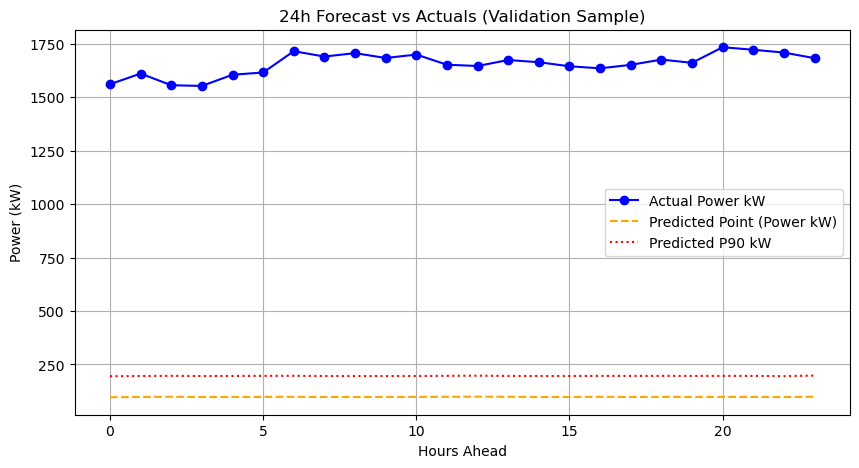

In [10]:
# ==========================================
# 6. Plot Validation Actuals vs Predictions
# ==========================================
print("Evaluating final model on a validation batch for a visual sanity check...")
val_dataset = ReeferDataset(df_val, input_features, 'Power_kW', seq_len=seq_len, pred_len=24)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

final_model.eval()
x_val, y_val_actual = next(iter(val_loader))
with torch.no_grad():
    pred_pw, pred_90 = final_model(x_val)

sample_idx = 0
plt.figure(figsize=(10,5))
plt.plot(y_val_actual[sample_idx].numpy(), label='Actual Power kW', color='blue', marker='o')
plt.plot(pred_pw[sample_idx].numpy(), label='Predicted Point (Power kW)', color='orange', linestyle='--')
plt.plot(pred_90[sample_idx].numpy(), label='Predicted P90 kW', color='red', linestyle=':')
plt.title("24h Forecast vs Actuals (Validation Sample)")
plt.xlabel("Hours Ahead")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# ==========================================
# 7. Generate Submission file
# ==========================================
df_targets = pd.read_csv(TARGETS_CSV)
df_targets['timestamp_utc_dt'] = pd.to_datetime(df_targets['timestamp_utc'].str.replace('Z', ''))

last_sequence = df_features.iloc[-seq_len:].copy()
x_input = torch.tensor(last_sequence[input_features].values, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    pred_pw, pred_90 = final_model(x_input)
    pw_24h = pred_pw[0].numpy()
    p90_24h = pred_90[0].numpy()

predictions = []
for i, row in df_targets.iterrows():
    idx = i % 24  
    pw = pw_24h[idx]
    p90 = p90_24h[idx]
    
    predictions.append({
        'timestamp_utc': row['timestamp_utc'],
        'pred_power_kw': max(0.0, round(float(pw), 6)),
        'pred_p90_kw': max(0.0, round(float(p90), 6))
    })

df_submission = pd.DataFrame(predictions)
df_submission.to_csv('baseline_submission.csv', index=False)
print("Saved test predictions to: baseline_submission.csv")
display(df_submission.head())

Saved test predictions to: baseline_submission.csv


,timestamp_utc,pred_power_kw,pred_p90_kw
0,2026-01-01T00:00:00Z,96.370522,194.495987
1,2026-01-01T01:00:00Z,97.613464,195.629425
2,2026-01-01T02:00:00Z,98.401176,196.328262
3,2026-01-01T03:00:00Z,97.532402,195.480225
4,2026-01-01T04:00:00Z,97.548294,195.814056
